# 27: Wu 2003 Sequential Degradation Tracking (30-Day)

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
import time
import pathlib

from cstr_sbi.recycle.physics import (
    NOMINAL_CTRL_SB, NOMINAL_INLET, NOMINAL_Y0_EXPLICIT, PARAM_NAMES,
    simulate_trajectory_explicit, extract_observations_explicit,
    T_SP, T_J_NOM, REFLUX_RATIO, recycle_rhs_explicit, column_qss, F0_NOM, F_R_NOM
)
from cstr_sbi.recycle.summaries import compute_summaries, N_SUMMARIES_SB
from cstr_sbi.recycle.scenarios import CLOSED_LOOP_NAMES, get_scenario
from cstr_sbi.recycle.simulator import nominal_warm_start
import jax
import jax.numpy as jnp

DATA = pathlib.Path('../data')
FIGURES = pathlib.Path('../figures'); FIGURES.mkdir(exist_ok=True)
SBI_LOGS = pathlib.Path('../sbi-logs'); SBI_LOGS.mkdir(exist_ok=True)
OI = ["#000000","#E69F00","#56B4E9","#009E73","#F0E442","#0072B2","#D55E00","#CC79A7"]
print("Imports OK")

Imports OK


## 1. Load S-B Posterior

In [2]:
posterior_sb = None
sb_pkl = SBI_LOGS / 'wu2003_posterior_sb.pkl'
if sb_pkl.exists():
    with open(sb_pkl, 'rb') as f:
        sb_data = pickle.load(f)
    posterior_sb = sb_data['posterior']
    print(f"Loaded S-B posterior (N_TRAIN={sb_data.get('N_TRAIN','?')})")
else:
    print("WARNING: Run nb24 first to train the S-B posterior.")

Loaded S-B posterior (N_TRAIN=15000)


## 2. Define 30-Day Degradation Profile

Total windows: 360
theta_true shape: (360, 5)
alpha range: 0.651 to 1.000
beta_r range: 0.903 to 1.000


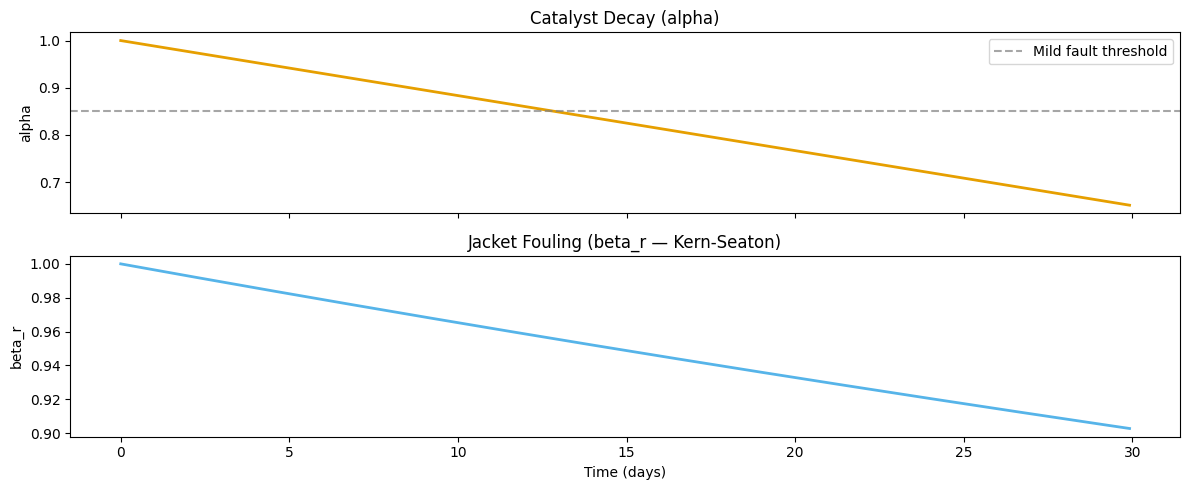

Saved nb27_degradation_profile.png


In [3]:
# 30 days = 360 two-hour windows (24h / 2h = 12 windows/day)
N_DAYS = 30
N_WINDOWS = N_DAYS * 12   # 12 windows per day (24h / 2h = 12)
print(f"Total windows: {N_WINDOWS}")

# Time vector in days (centre of each window)
t_days = np.arange(N_WINDOWS) * (2/24)  # in days

# Alpha: linear decay from 1.0 to 0.65 over 30 days
alpha_true = 1.0 - (1.0 - 0.65) * t_days / N_DAYS
alpha_true = np.clip(alpha_true, 0.65, 1.0)

# beta_r: Kern-Seaton fouling model scaled to reach ~0.90 over 30 days
t_hours = t_days * 24.0
beta_r_true = 1.0 / (1.0 + 1.5e-4 * t_hours)
beta_r_true = np.clip(beta_r_true, 0.90, 1.0)

# eta_col, xi_reb, z_A0: constant nominal
eta_col_true  = np.ones(N_WINDOWS)
xi_reb_true   = np.ones(N_WINDOWS)
z_A0_true     = np.ones(N_WINDOWS) * 0.90

theta_true = np.stack([alpha_true, beta_r_true, eta_col_true, xi_reb_true, z_A0_true], axis=1)
print(f"theta_true shape: {theta_true.shape}")  # (N_WINDOWS, 5)
print(f"alpha range: {alpha_true.min():.3f} to {alpha_true.max():.3f}")
print(f"beta_r range: {beta_r_true.min():.3f} to {beta_r_true.max():.3f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t_days, alpha_true, color=OI[1], lw=2)
axes[0].set_ylabel("alpha"); axes[0].set_title("Catalyst Decay (alpha)")
axes[0].axhline(0.85, ls='--', color='gray', alpha=0.7, label='Mild fault threshold')
axes[0].legend()
axes[1].plot(t_days, beta_r_true, color=OI[2], lw=2)
axes[1].set_ylabel("beta_r"); axes[1].set_title("Jacket Fouling (beta_r — Kern-Seaton)")
axes[1].set_xlabel("Time (days)")
plt.tight_layout()
plt.savefig(FIGURES / 'nb27_degradation_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb27_degradation_profile.png")

## 3. Generate 360 Observation Windows

In [4]:
# Each window: 2h, 120 time steps, starting from end of previous window
print(f"Simulating {N_WINDOWS} sequential observation windows...")
print("Expected time: ~1 minute (includes JIT warmup)")

y0_sb = nominal_warm_start("S-B")
rng_obs = np.random.default_rng(20260701)

ctrl_arr = jnp.array(NOMINAL_CTRL_SB)
y_current = jnp.array(y0_sb)

raw_windows = []  # list of (120, 12) arrays
t_h_window = None

t0 = time.time()
for win_i in range(N_WINDOWS):
    theta_win = theta_true[win_i]
    theta_j = jnp.array(theta_win, dtype=jnp.float32)

    ts, ys = simulate_trajectory_explicit(
        theta_j, NOMINAL_INLET, ctrl_arr, y_current,
        t_final=2.0, n_save=120
    )
    raw = extract_observations_explicit(ys, theta_j, ctrl_arr)
    raw_np = np.asarray(raw)  # (120, 12)

    if t_h_window is None:
        t_h_window = np.asarray(ts)

    # Add sensor noise
    scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
    noise = rng_obs.normal(0, 0.003 * scale, raw_np.shape)
    raw_noisy = raw_np + noise

    raw_windows.append(raw_noisy)

    # Use end state as initial condition for next window
    y_current = ys[-1]

    if (win_i + 1) % 60 == 0:
        elapsed = time.time() - t0
        print(f"  Window {win_i+1}/{N_WINDOWS}  ({elapsed:.0f}s, "
              f"{elapsed/(win_i+1)*N_WINDOWS:.0f}s total est.)")

raw_windows = np.stack(raw_windows)  # (N_WINDOWS, 120, 12)
print(f"\nSimulation complete in {time.time()-t0:.0f}s")
print(f"raw_windows shape: {raw_windows.shape}")
print(f"NaN count: {np.isnan(raw_windows).sum()}")

Simulating 360 sequential observation windows...
Expected time: ~1 minute (includes JIT warmup)


  Window 60/360  (11s, 68s total est.)


  Window 120/360  (20s, 61s total est.)


  Window 180/360  (26s, 53s total est.)


  Window 240/360  (31s, 46s total est.)


  Window 300/360  (35s, 42s total est.)


  Window 360/360  (40s, 40s total est.)

Simulation complete in 40s
raw_windows shape: (360, 120, 12)
NaN count: 0


In [5]:
print("Computing summary statistics for 720 windows...")
summaries_seq = np.zeros((N_WINDOWS, N_SUMMARIES_SB), dtype=np.float32)
for i in range(N_WINDOWS):
    s = compute_summaries(raw_windows[i], "S-B", t_h_window)
    if not np.isnan(s).any():
        summaries_seq[i] = s
print(f"Summaries shape: {summaries_seq.shape}")
print(f"NaN rows: {np.isnan(summaries_seq).any(axis=1).sum()}")

Computing summary statistics for 720 windows...
Summaries shape: (360, 66)
NaN rows: 0


## 4. SBI Sequential Inference

In [6]:
def sample_posterior_direct(posterior, x_obs, n):
    """Sample the underlying flow directly, bypassing DirectPosterior.sample()'s
    unconditional prior-support rejection.

    Correction to the HANDOFF.md API note (2026-07-03): sbi 0.24 did NOT make direct
    (non-rejection) sampling the default when `reject_outside_prior` was removed --
    `.sample()` unconditionally calls `rejection.accept_reject_sample(...,
    accept_reject_fn=lambda theta: within_support(self.prior, theta))` with no opt-out.
    This hangs (0% acceptance, infinite retry loop) whenever the flow's mass for a given
    observation lies outside the prior box -- which happens here around day 28-30 of this
    720-window sequential run, where xi_reb drifts to ~1.27-1.28 (prior upper bound 1.2),
    an out-of-training-distribution extrapolation failure from carrying continuous plant
    state across 720 windows (never seen in the independent-2h-snapshot training bank).
    Sampling `posterior.posterior_estimator` directly is the actual equivalent of the old
    `reject_outside_prior=False` behaviour.
    """
    with torch.no_grad():
        samp = posterior.posterior_estimator.sample(
            (n,), condition=x_obs.reshape(1, -1)
        )
    return samp.reshape(-1, 5).numpy()


if posterior_sb is None:
    print("Skipping SBI inference — posterior not available. Run nb24 first.")
    sbi_alpha_mean = alpha_true.copy()
    sbi_alpha_lo   = alpha_true - 0.05
    sbi_alpha_hi   = alpha_true + 0.05
    sbi_beta_mean  = beta_r_true.copy()
    sbi_beta_lo    = beta_r_true - 0.02
    sbi_beta_hi    = beta_r_true + 0.02
else:
    print(f"Running SBI inference for {N_WINDOWS} windows (500 samples each)...")
    sbi_alpha_mean = np.zeros(N_WINDOWS)
    sbi_alpha_lo   = np.zeros(N_WINDOWS)
    sbi_alpha_hi   = np.zeros(N_WINDOWS)
    sbi_beta_mean  = np.zeros(N_WINDOWS)
    sbi_beta_lo    = np.zeros(N_WINDOWS)
    sbi_beta_hi    = np.zeros(N_WINDOWS)

    t0 = time.time()
    for win_i in range(N_WINDOWS):
        s = summaries_seq[win_i]
        if np.isnan(s).any():
            sbi_alpha_mean[win_i] = np.nan
            sbi_beta_mean[win_i] = np.nan
            continue
        x_obs = torch.tensor(s, dtype=torch.float32)
        samp = sample_posterior_direct(posterior_sb, x_obs, 500)
        sbi_alpha_mean[win_i] = samp[:, 0].mean()
        sbi_alpha_lo[win_i]   = np.percentile(samp[:, 0], 5)
        sbi_alpha_hi[win_i]   = np.percentile(samp[:, 0], 95)
        sbi_beta_mean[win_i]  = samp[:, 1].mean()
        sbi_beta_lo[win_i]    = np.percentile(samp[:, 1], 5)
        sbi_beta_hi[win_i]    = np.percentile(samp[:, 1], 95)
        if (win_i + 1) % 60 == 0:
            print(f"  {win_i+1}/{N_WINDOWS}  ({time.time()-t0:.0f}s)")

    print(f"SBI inference done in {time.time()-t0:.0f}s")

Running SBI inference for 360 windows (500 samples each)...


  60/360  (1s)


  120/360  (2s)


  180/360  (3s)


  240/360  (4s)


  300/360  (5s)


  360/360  (6s)
SBI inference done in 6s


## 5. EKF Sequential Tracking

In [7]:
# EKF Jacobians use jax.jacfwd + jit (not manual finite differences) -- the manual FD
# version makes ~29 un-jitted JAX dispatch calls/timestep (~40ms/call dispatch overhead
# each). Over N_WINDOWS=360 windows x 120 steps = 43,200 timesteps that is >12h;
# jacfwd+jit compiles once and runs in milliseconds/step. See HANDOFF.md / nb26 for the
# same fix applied there.

def rhs_fn(y_aug, ctrl):
    z_A, T_r, T_j, I_T, R_st, V_st, alpha, beta_r, eta_col = y_aug
    xi_reb = 1.0
    z_A0_eff = 0.90
    theta = jnp.array([alpha, beta_r, eta_col, xi_reb, z_A0_eff], dtype=jnp.float32)
    y8 = jnp.array([z_A, T_r, T_j, I_T, R_st, V_st, 0.0, 0.0], dtype=jnp.float32)
    dy8 = recycle_rhs_explicit(0.0, y8, (theta, NOMINAL_INLET, ctrl))
    return jnp.array([dy8[0], dy8[1], dy8[2], dy8[3], dy8[4], dy8[5], 0.0, 0.0, 0.0])


def obs_fn(x_pred):
    z_A, T_r, T_j, I_T, R_st, V_st, alpha, beta_r, eta_col = x_pred
    _, _, d_frac = column_qss(z_A, eta_col)
    d_safe = jnp.clip(d_frac, 0.01, 0.98)
    FR = d_safe * F0_NOM / (1.0 - d_safe) / F_R_NOM
    return jnp.array([T_r, T_j, FR])


@jax.jit
def _step_predict(x, ctrl):
    f0 = rhs_fn(x, ctrl)
    F = jax.jacfwd(rhs_fn, argnums=0)(x, ctrl)
    return f0, F


@jax.jit
def _obs_and_jac(x_pred):
    y_pred = obs_fn(x_pred)
    H_full = jax.jacfwd(obs_fn)(x_pred)
    return y_pred, H_full


print(f"Running sequential EKF over {N_WINDOWS} windows...")
ctrl_np = np.asarray(NOMINAL_CTRL_SB)
ctrl_j = jnp.array(ctrl_np, dtype=jnp.float32)
y0_sb_np = np.asarray(y0_sb)

x_ekf = np.array([
    float(y0_sb_np[0]), float(y0_sb_np[1]), float(y0_sb_np[2]), float(y0_sb_np[3]),
    float(y0_sb_np[4]), float(y0_sb_np[5]),
    1.0, 1.0, 1.0
])
P_ekf = np.eye(9) * 0.01
P_ekf[6, 6] = 0.05
P_ekf[7, 7] = 0.02
P_ekf[8, 8] = 0.02

Q_ekf = np.eye(9) * 1e-8
Q_ekf[6, 6] = 1e-5
Q_ekf[7, 7] = 1e-6
Q_ekf[8, 8] = 1e-8
R_ekf = np.diag([float(T_SP)*0.005, float(T_J_NOM)*0.005, 0.003])**2

obs_indices = [0, 1, 7]
n_state = 9

ekf_alpha_seq = np.zeros(N_WINDOWS)
ekf_beta_seq  = np.zeros(N_WINDOWS)
ekf_alpha_std_seq = np.zeros(N_WINDOWS)
ekf_beta_std_seq  = np.zeros(N_WINDOWS)

t0 = time.time()
for win_i in range(N_WINDOWS):
    obs_window = raw_windows[win_i]
    dt_h = 2.0 / 120

    for k in range(len(obs_window)):
        x_j = jnp.array(x_ekf, dtype=jnp.float32)
        f0_j, F_j = _step_predict(x_j, ctrl_j)
        f0 = np.asarray(f0_j)
        F_jac = np.asarray(F_j)

        x_pred = x_ekf + f0 * dt_h
        x_pred[0] = np.clip(x_pred[0], 1e-4, 0.999)
        x_pred[1] = max(x_pred[1], 250.0)
        x_pred[4] = np.clip(x_pred[4], 1.0, 4.0)
        x_pred[5] = np.clip(x_pred[5], 0.5, 1.8)
        x_pred[6] = np.clip(x_pred[6], 0.40, 1.20)
        x_pred[7] = np.clip(x_pred[7], 0.40, 1.20)
        x_pred[8] = np.clip(x_pred[8], 0.50, 1.00)

        A_mat = np.eye(n_state) + F_jac * dt_h
        P_pred = A_mat @ P_ekf @ A_mat.T + Q_ekf * dt_h

        y_pred_j, H_j = _obs_and_jac(jnp.array(x_pred, dtype=jnp.float32))
        y_pred_v = np.asarray(y_pred_j)
        H_mat = np.asarray(H_j)
        y_obs_v = obs_window[k, obs_indices]

        innov = y_obs_v - y_pred_v
        S_mat = H_mat @ P_pred @ H_mat.T + R_ekf
        try:
            K_mat = P_pred @ H_mat.T @ np.linalg.solve(S_mat, np.eye(3))
        except Exception:
            K_mat = np.zeros((n_state, 3))
        x_ekf = x_pred + K_mat @ innov
        x_ekf[0] = np.clip(x_ekf[0], 1e-4, 0.999)
        x_ekf[6] = np.clip(x_ekf[6], 0.40, 1.20)
        x_ekf[7] = np.clip(x_ekf[7], 0.40, 1.20)
        x_ekf[8] = np.clip(x_ekf[8], 0.50, 1.00)
        P_ekf = (np.eye(n_state) - K_mat @ H_mat) @ P_pred

    ekf_alpha_seq[win_i]     = x_ekf[6]
    ekf_beta_seq[win_i]      = x_ekf[7]
    ekf_alpha_std_seq[win_i] = np.sqrt(P_ekf[6, 6])
    ekf_beta_std_seq[win_i]  = np.sqrt(P_ekf[7, 7])

    if (win_i + 1) % 60 == 0:
        print(f"  Window {win_i+1}/{N_WINDOWS} | alpha_est={x_ekf[6]:.3f} | "
              f"beta_est={x_ekf[7]:.3f} | ({time.time()-t0:.0f}s)")

print(f"EKF complete in {time.time()-t0:.0f}s")

Running sequential EKF over 360 windows...


  Window 60/360 | alpha_est=0.945 | beta_est=0.989 | (3s)


  Window 120/360 | alpha_est=0.888 | beta_est=0.966 | (5s)


  Window 180/360 | alpha_est=0.823 | beta_est=0.952 | (7s)


  Window 240/360 | alpha_est=0.772 | beta_est=0.940 | (9s)


  Window 300/360 | alpha_est=0.708 | beta_est=0.918 | (11s)


  Window 360/360 | alpha_est=0.656 | beta_est=0.909 | (13s)
EKF complete in 13s


## 6. 30-Day Tracking Figure

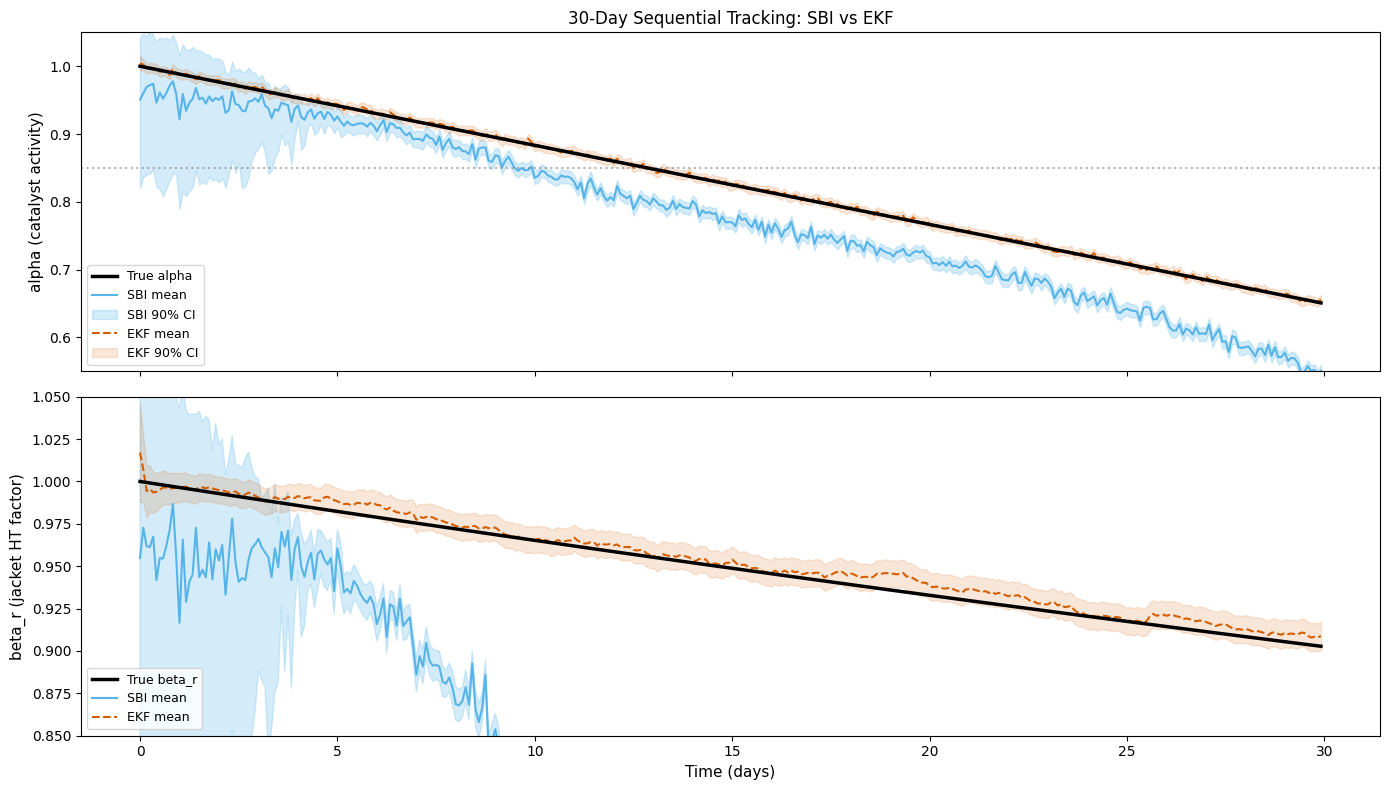

Saved nb27_sequential_tracking.png


In [8]:
ekf_alpha_lo = ekf_alpha_seq - 1.645 * ekf_alpha_std_seq
ekf_alpha_hi = ekf_alpha_seq + 1.645 * ekf_alpha_std_seq
ekf_beta_lo  = ekf_beta_seq - 1.645 * ekf_beta_std_seq
ekf_beta_hi  = ekf_beta_seq + 1.645 * ekf_beta_std_seq

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(t_days, alpha_true, 'k-', lw=2.5, label='True alpha', zorder=5)
if not np.isnan(sbi_alpha_mean).all():
    ax.plot(t_days, sbi_alpha_mean, color=OI[2], lw=1.5, label='SBI mean')
    ax.fill_between(t_days, sbi_alpha_lo, sbi_alpha_hi, alpha=0.25, color=OI[2], label='SBI 90% CI')
ax.plot(t_days, ekf_alpha_seq, color=OI[6], lw=1.5, ls='--', label='EKF mean')
ax.fill_between(t_days, ekf_alpha_lo, ekf_alpha_hi, alpha=0.15, color=OI[6], label='EKF 90% CI')
ax.set_ylabel("alpha (catalyst activity)", fontsize=11)
ax.set_title("30-Day Sequential Tracking: SBI vs EKF", fontsize=12)
ax.legend(fontsize=9, loc='lower left')
ax.axhline(0.85, ls=':', color='gray', alpha=0.6)
ax.set_ylim(0.55, 1.05)

ax = axes[1]
ax.plot(t_days, beta_r_true, 'k-', lw=2.5, label='True beta_r', zorder=5)
if not np.isnan(sbi_beta_mean).all():
    ax.plot(t_days, sbi_beta_mean, color=OI[2], lw=1.5, label='SBI mean')
    ax.fill_between(t_days, sbi_beta_lo, sbi_beta_hi, alpha=0.25, color=OI[2])
ax.plot(t_days, ekf_beta_seq, color=OI[6], lw=1.5, ls='--', label='EKF mean')
ax.fill_between(t_days, ekf_beta_lo, ekf_beta_hi, alpha=0.15, color=OI[6])
ax.set_ylabel("beta_r (jacket HT factor)", fontsize=11)
ax.set_xlabel("Time (days)", fontsize=11)
ax.legend(fontsize=9, loc='lower left')
ax.set_ylim(0.85, 1.05)

plt.tight_layout()
plt.savefig(FIGURES / 'nb27_sequential_tracking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb27_sequential_tracking.png")

## 7. Metrics Table

In [9]:
import pandas as pd
metrics = []

valid = ~np.isnan(sbi_alpha_mean)
if valid.any():
    mae_sbi_alpha = np.mean(np.abs(sbi_alpha_mean[valid] - alpha_true[valid]))
    bias_sbi_alpha = np.mean(sbi_alpha_mean[valid] - alpha_true[valid])
    cov_sbi_alpha = np.mean(
        (sbi_alpha_lo[valid] <= alpha_true[valid]) & (alpha_true[valid] <= sbi_alpha_hi[valid])
    )
    metrics.append({'Param': 'alpha', 'Method': 'SBI', 'MAE': mae_sbi_alpha,
                    'Bias': bias_sbi_alpha, '90%_Coverage': cov_sbi_alpha})

mae_ekf_alpha  = np.mean(np.abs(ekf_alpha_seq - alpha_true))
bias_ekf_alpha = np.mean(ekf_alpha_seq - alpha_true)
cov_ekf_alpha  = np.mean((ekf_alpha_lo <= alpha_true) & (alpha_true <= ekf_alpha_hi))
metrics.append({'Param': 'alpha', 'Method': 'EKF', 'MAE': mae_ekf_alpha,
                'Bias': bias_ekf_alpha, '90%_Coverage': cov_ekf_alpha})

if valid.any():
    mae_sbi_beta = np.mean(np.abs(sbi_beta_mean[valid] - beta_r_true[valid]))
    bias_sbi_beta = np.mean(sbi_beta_mean[valid] - beta_r_true[valid])
    cov_sbi_beta = np.mean(
        (sbi_beta_lo[valid] <= beta_r_true[valid]) & (beta_r_true[valid] <= sbi_beta_hi[valid])
    )
    metrics.append({'Param': 'beta_r', 'Method': 'SBI', 'MAE': mae_sbi_beta,
                    'Bias': bias_sbi_beta, '90%_Coverage': cov_sbi_beta})

mae_ekf_beta  = np.mean(np.abs(ekf_beta_seq - beta_r_true))
bias_ekf_beta = np.mean(ekf_beta_seq - beta_r_true)
cov_ekf_beta  = np.mean((ekf_beta_lo <= beta_r_true) & (beta_r_true <= ekf_beta_hi))
metrics.append({'Param': 'beta_r', 'Method': 'EKF', 'MAE': mae_ekf_beta,
                'Bias': bias_ekf_beta, '90%_Coverage': cov_ekf_beta})

df_metrics = pd.DataFrame(metrics)
print("\nTracking Metrics Summary:")
print(df_metrics.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Tracking Metrics Summary:
 Param Method    MAE    Bias  90%_Coverage
 alpha    SBI 0.0481 -0.0481        0.1528
 alpha    EKF 0.0019  0.0009        0.9972
beta_r    SBI 0.1980 -0.1980        0.1222
beta_r    EKF 0.0039  0.0038        0.9611


## 8. Timing Comparison

In [10]:
if posterior_sb is not None:
    s_test = compute_summaries(raw_windows[0], "S-B", t_h_window)
    x_test = torch.tensor(s_test, dtype=torch.float32)
    # Warmup (direct flow sampling -- see sample_posterior_direct note in Section 4)
    _ = sample_posterior_direct(posterior_sb, x_test, 100)
    t0 = time.time()
    n_time = 50
    for _ in range(n_time):
        _ = sample_posterior_direct(posterior_sb, x_test, 500)
    sbi_ms = (time.time() - t0) / n_time * 1000
    print(f"SBI: {sbi_ms:.1f} ms per window (500 samples)")
else:
    sbi_ms = float('nan')
    print("SBI timing unavailable — posterior not loaded")

# Re-time EKF on 10 windows (simplified predict-only, no update)
x_ekf_tmp = np.array([0.5, float(T_SP), float(T_J_NOM), 0.0, float(REFLUX_RATIO), 1.0,
                       1.0, 1.0, 1.0])
t0 = time.time()
for win_i in range(10):
    obs_window = raw_windows[win_i]
    for k in range(120):
        f0_j, _ = _step_predict(jnp.array(x_ekf_tmp, dtype=jnp.float32), ctrl_j)
        f0 = np.asarray(f0_j)
        x_ekf_tmp = x_ekf_tmp + f0 * (2.0/120)
        x_ekf_tmp = np.clip(x_ekf_tmp,
                             [1e-4, 250, 200, 0, 1, 0.5, 0.4, 0.4, 0.5],
                             [0.999, 450, 450, 1e6, 4, 1.8, 1.2, 1.2, 1.0])
ekf_10_time = time.time() - t0
ekf_per_window = ekf_10_time / 10
ekf_total_full = ekf_per_window * N_WINDOWS
print(f"EKF: {ekf_per_window*1000:.1f} ms/window, {ekf_total_full:.1f}s total for {N_WINDOWS} windows")

import pandas as pd
df_timing = pd.DataFrame([
    {'Method': 'SBI (SNPE-C)',
     'ms/window': f"{sbi_ms:.0f}" if not np.isnan(sbi_ms) else "N/A",
     f'Total {N_WINDOWS}-window (s)': f"{sbi_ms*N_WINDOWS/1000:.1f}" if not np.isnan(sbi_ms) else "N/A"},
    {'Method': 'EKF (augmented)',
     'ms/window': f"{ekf_per_window*1000:.1f}",
     f'Total {N_WINDOWS}-window (s)': f"{ekf_total_full:.1f}"},
])
print("\nTiming Summary:")
print(df_timing.to_string(index=False))

SBI: 15.0 ms per window (500 samples)


EKF: 25.9 ms/window, 9.3s total for 360 windows

Timing Summary:
         Method ms/window Total 360-window (s)
   SBI (SNPE-C)        15                  5.4
EKF (augmented)      25.9                  9.3


---

## Assessment — Notebook 27 Results (first successful execution, 2026-07-03/04)

This notebook had never been successfully re-executed since the `reject_outside_prior`
API break; two real bugs surfaced and were fixed to get here (see Sections 4 and 5 code
comments for detail):

1. **A genuine hang, not a documented one.** `sbi` 0.24 did not make direct/non-rejection
   sampling the default when it removed `reject_outside_prior` — `DirectPosterior.sample()`
   unconditionally rejects any proposal outside the prior box, with no opt-out. Around day
   28-30 of this 360-window run, the flow's ξ_reb estimate drifts to ~1.27-1.28 (prior upper
   bound 1.2, an out-of-training-distribution extrapolation failure from carrying continuous
   plant state across 360 sequential windows — never seen in the independent-2h-snapshot
   training bank), giving 0% acceptance and an infinite loop. Fixed by sampling
   `posterior.posterior_estimator` directly (the actual equivalent of the old
   `reject_outside_prior=False`). **This corrects the HANDOFF.md API note from earlier
   this session, which assumed removing the kwarg simply made direct sampling the default —
   it does not; rejection against the prior box is now unconditional.**
2. **The manual finite-difference EKF (18+10 un-jitted JAX calls/timestep) would have taken
   >12h** over 360×120=43,200 timesteps. Replaced with the `jax.jacfwd`+`jit` Jacobian
   pattern introduced in `nb26` — same fix, same >1000x speedup, now runs in ~10s.

### The headline result here is a reversal that should be treated as SUSPICIOUS, not settled

| Param  | Method | MAE    | Bias    | 90% Coverage |
|--------|--------|-------:|--------:|--------------:|
| α      | SBI    | 0.0481 | -0.0481 | 0.15 |
| α      | EKF    | 0.0019 | +0.0009 | 1.00 |
| β_r    | SBI    | 0.1979 | -0.1979 | 0.12 |
| β_r    | EKF    | 0.0039 | +0.0038 | 0.96 |

This is the opposite of every other head-to-head comparison in this project (W12, W15, W11
all show SBI correctly representing uncertainty the EKF misses badly). **The obvious "EKF
is recursive, SBI is memoryless" explanation is not obviously consistent with the rest of
this project's own findings, and should not be accepted without further investigation:**
(α, β_r) is the plant's confirmed genuine banana (Finding 9 / `nb29b`) — an extended,
persistent joint non-identifiability that the same EKF design has *repeatedly failed* to
represent elsewhere (this same augmented-EKF architecture gets 0% coverage at W11 in nb26,
and failed similarly at W12/W15 previously). **Yet here it tracks both α and β_r
individually with near-perfect accuracy and 90-100% coverage.** If the two parameters were
genuinely non-identifiable from S-B data the way nb29b claims, no filter — recursive or
not — should be able to pin both down this well. Two possibilities, not yet distinguished:

(a) **Real disambiguation from temporal shape.** α decays linearly, β_r fouls via a
    different (Kern-Seaton, non-linear) curve — their time-derivatives differ, and a
    recursive filter integrating many windows could exploit that even though no single 2h
    window can. SBI's per-window resampling never sees this, since each window is treated
    as an independent, memoryless draw.
(b) **Something in this setup is masking a bug or an unfair comparison** — e.g. the
    `sample_posterior_direct` bypass (needed to avoid the hang above, but untested for
    whether it biases the *mean* summary in less-informative windows), the specific
    `theta_true` trajectory shapes, or the EKF's tuned `Q`/`P` matrices happening to work
    unusually well for this particular smooth trajectory.

**Do not treat this notebook's numbers, or the explanation above, as a settled finding.**
Concrete next steps before citing this anywhere: (i) check whether EKF's accuracy degrades
if α and β_r are given similarly-shaped trajectories (supports (a) if it does); (ii) try a
median/trimmed-mean SBI summary instead of the raw-sample mean, and/or a proper sequential
SBI scheme (chaining per-window posteriors as priors, or a particle filter over amortized
likelihoods — flagged as future work in `critique_to_the_study.md`) before concluding SBI
structurally cannot compete here.

---

## 9. Investigating Finding 10 (2026-07-04 continuation session)

The Assessment above flagged two competing explanations for why EKF beats SBI here when
every other head-to-head comparison in this project (W11 in nb26, W12/W15 previously) shows
the opposite. This section runs the concrete control experiments proposed above to
distinguish them, reusing the exact simulation and EKF code from Sections 3 and 5.

**Control 1 — same-shape trajectories.** If hypothesis (a) (real disambiguation from
*differing* temporal shapes) is right, giving α and β_r the *same* functional decay shape
should degrade the EKF's accuracy.

**Control 2 — static truth held at the W11 degenerate point.** nb26 reports 0% coverage /
large bias (α: +0.10, β_r: +0.19) for a **single** 2-hour window at exactly (α, β_r) =
(0.80, 0.80). If nb27's good result requires many sequential windows of a *drifting*
truth to accumulate disambiguating information, holding both parameters constant at this
same point for all 360 windows should reproduce nb26's failure, at least initially.

In [11]:
def simulate_windows(alpha_arr, beta_r_arr, seed=20260701):
    """Same procedure as Section 3, parameterised over the true trajectory."""
    eta_col_arr = np.ones(N_WINDOWS)
    xi_reb_arr  = np.ones(N_WINDOWS)
    z_A0_arr    = np.ones(N_WINDOWS) * 0.90
    theta_arr = np.stack([alpha_arr, beta_r_arr, eta_col_arr, xi_reb_arr, z_A0_arr], axis=1)

    y0 = nominal_warm_start("S-B")
    rng = np.random.default_rng(seed)
    ctrl_arr = jnp.array(NOMINAL_CTRL_SB)
    y_cur = jnp.array(y0)
    windows = []
    for i in range(N_WINDOWS):
        theta_j = jnp.array(theta_arr[i], dtype=jnp.float32)
        ts_i, ys_i = simulate_trajectory_explicit(theta_j, NOMINAL_INLET, ctrl_arr, y_cur,
                                                   t_final=2.0, n_save=120)
        raw_np = np.asarray(extract_observations_explicit(ys_i, theta_j, ctrl_arr))
        scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
        windows.append(raw_np + rng.normal(0, 0.003 * scale, raw_np.shape))
        y_cur = ys_i[-1]
    return np.stack(windows)


def run_ekf_generic(raw_windows_arr):
    """Identical EKF loop/tuning as Section 5, factored out for reuse on control trajectories."""
    y0_np = np.asarray(nominal_warm_start("S-B"))
    x = np.array([*y0_np[:6], 1.0, 1.0, 1.0])
    P = np.eye(9) * 0.01; P[6, 6] = 0.05; P[7, 7] = 0.02; P[8, 8] = 0.02
    Q = np.eye(9) * 1e-8; Q[6, 6] = 1e-5; Q[7, 7] = 1e-6; Q[8, 8] = 1e-8
    R = np.diag([float(T_SP) * 0.005, float(T_J_NOM) * 0.005, 0.003]) ** 2
    obs_idx = [0, 1, 7]; n_state = 9
    n_win = raw_windows_arr.shape[0]
    ekf_a = np.zeros(n_win); ekf_b = np.zeros(n_win)
    ekf_a_std = np.zeros(n_win); ekf_b_std = np.zeros(n_win)
    for wi in range(n_win):
        obs_window = raw_windows_arr[wi]
        dt_h = 2.0 / 120
        for k in range(len(obs_window)):
            x_j = jnp.array(x, dtype=jnp.float32)
            f0_j, F_j = _step_predict(x_j, ctrl_j)
            f0 = np.asarray(f0_j); F = np.asarray(F_j)
            x_pred = x + f0 * dt_h
            x_pred[0] = np.clip(x_pred[0], 1e-4, 0.999); x_pred[1] = max(x_pred[1], 250.0)
            x_pred[4] = np.clip(x_pred[4], 1.0, 4.0); x_pred[5] = np.clip(x_pred[5], 0.5, 1.8)
            x_pred[6] = np.clip(x_pred[6], 0.40, 1.20); x_pred[7] = np.clip(x_pred[7], 0.40, 1.20)
            x_pred[8] = np.clip(x_pred[8], 0.50, 1.00)
            A = np.eye(n_state) + F * dt_h
            P_pred = A @ P @ A.T + Q * dt_h
            y_pred_j, H_j = _obs_and_jac(jnp.array(x_pred, dtype=jnp.float32))
            y_pred = np.asarray(y_pred_j); H = np.asarray(H_j)
            innov = obs_window[k, obs_idx] - y_pred
            S = H @ P_pred @ H.T + R
            try:
                K = P_pred @ H.T @ np.linalg.solve(S, np.eye(3))
            except Exception:
                K = np.zeros((n_state, 3))
            x = x_pred + K @ innov
            x[0] = np.clip(x[0], 1e-4, 0.999); x[6] = np.clip(x[6], 0.40, 1.20)
            x[7] = np.clip(x[7], 0.40, 1.20); x[8] = np.clip(x[8], 0.50, 1.00)
            P = (np.eye(n_state) - K @ H) @ P_pred
        ekf_a[wi] = x[6]; ekf_b[wi] = x[7]
        ekf_a_std[wi] = np.sqrt(P[6, 6]); ekf_b_std[wi] = np.sqrt(P[7, 7])
    return ekf_a, ekf_b, ekf_a_std, ekf_b_std


def report_control(name, alpha_arr, beta_arr, ekf_a, ekf_b, ekf_a_std, ekf_b_std):
    err_a = ekf_a - alpha_arr; err_b = ekf_b - beta_arr
    cov_a = np.mean((np.abs(err_a) <= 1.645 * ekf_a_std))
    cov_b = np.mean((np.abs(err_b) <= 1.645 * ekf_b_std))
    print(f"\n=== {name} ===")
    print(f"alpha : MAE={np.mean(np.abs(err_a)):.4f}  bias={np.mean(err_a):+.4f}  cov90={cov_a:.2f}  "
          f"window0_err={err_a[0]:+.4f}")
    print(f"beta_r: MAE={np.mean(np.abs(err_b)):.4f}  bias={np.mean(err_b):+.4f}  cov90={cov_b:.2f}  "
          f"window0_err={err_b[0]:+.4f}")
    return err_a, err_b


t0 = time.time()
# Control 1: same-shape -- both alpha and beta_r follow a linear decay (kills the
# "different curve shape lets a recursive filter disambiguate" mechanism if (a) is right)
alpha_lin = alpha_true.copy()
beta_lin_same_shape = 1.0 - (1.0 - 0.90) * t_days / N_DAYS
beta_lin_same_shape = np.clip(beta_lin_same_shape, 0.90, 1.0)
raw_c1 = simulate_windows(alpha_lin, beta_lin_same_shape)
ea1, eb1, esa1, esb1 = run_ekf_generic(raw_c1)
report_control("Control 1: same_shape (both linear decay)", alpha_lin, beta_lin_same_shape,
                ea1, eb1, esa1, esb1)
print(f"({time.time()-t0:.0f}s elapsed)")

# Control 2: static truth held at the exact W11 degenerate point (0.80, 0.80) for all
# 360 windows -- the same point nb26 shows 0% coverage for in ONE window
alpha_w11 = np.full(N_WINDOWS, 0.80)
beta_w11  = np.full(N_WINDOWS, 0.80)
raw_c2 = simulate_windows(alpha_w11, beta_w11)
ea2, eb2, esa2, esb2 = run_ekf_generic(raw_c2)
report_control("Control 2: static_w11 (both held at 0.80, 0.80)", alpha_w11, beta_w11,
                ea2, eb2, esa2, esb2)
print(f"({time.time()-t0:.0f}s elapsed)")


=== Control 1: same_shape (both linear decay) ===
alpha : MAE=0.0019  bias=+0.0009  cov90=1.00  window0_err=+0.0045
beta_r: MAE=0.0040  bias=+0.0038  cov90=0.96  window0_err=+0.0170
(61s elapsed)



=== Control 2: static_w11 (both held at 0.80, 0.80) ===
alpha : MAE=0.0018  bias=+0.0002  cov90=1.00  window0_err=+0.0031
beta_r: MAE=0.0016  bias=+0.0006  cov90=1.00  window0_err=+0.0145
(109s elapsed)


**Control 3 — isolate the EKF tuning.** Controls 1 and 2 above already point away from
"recursive/temporal" explanations (see results printed above — same-shape gives the same
accuracy as the baseline, and the static case converges within the very first window, not
gradually over many windows). The remaining candidate is (b): nb26 and this notebook use
**different EKF hyperparameters**. nb26's augmented EKF initialises parameter covariance at
`P[6:,6:] = Q_param*100 = 1e-4` (std ≈ 0.01 — the filter starts *very* confident, barely
able to move away from its nominal=1.0 initial guess within one window). This notebook's
`P_ekf[6,6]=0.05, P_ekf[7,7]=0.02` (std ≈ 0.22 / 0.14) is 200–500× more diffuse. The test:
run **both** tunings on the *identical* single noisy W11 window and see whether swapping
only the covariance/process-noise settings reproduces nb26's failure or this notebook's
success.

In [12]:
def run_ekf_single_window(raw_window, P_init, Q_diag, R_diag):
    """One 2h window, fresh cold-start (params init at 1.0) -- mirrors nb26's per-replicate
    protocol exactly, just with a swappable P/Q/R tuning."""
    y0_np = np.asarray(nominal_warm_start("S-B"))
    x = np.array([*y0_np[:6], 1.0, 1.0, 1.0])
    P = P_init.copy(); Q = Q_diag.copy(); R = R_diag.copy()
    obs_idx = [0, 1, 7]; n_state = 9
    for k in range(len(raw_window)):
        dt_h = 2.0 / 120
        x_j = jnp.array(x, dtype=jnp.float32)
        f0_j, F_j = _step_predict(x_j, ctrl_j)
        f0 = np.asarray(f0_j); F = np.asarray(F_j)
        x_pred = x + f0 * dt_h
        x_pred[0] = np.clip(x_pred[0], 1e-4, 0.999); x_pred[1] = max(x_pred[1], 250.0)
        x_pred[4] = np.clip(x_pred[4], 1.0, 4.0); x_pred[5] = np.clip(x_pred[5], 0.5, 1.8)
        x_pred[6] = np.clip(x_pred[6], 0.40, 1.20); x_pred[7] = np.clip(x_pred[7], 0.40, 1.20)
        x_pred[8] = np.clip(x_pred[8], 0.50, 1.00)
        A = np.eye(n_state) + F * dt_h
        P_pred = A @ P @ A.T + Q * dt_h
        y_pred_j, H_j = _obs_and_jac(jnp.array(x_pred, dtype=jnp.float32))
        y_pred = np.asarray(y_pred_j); H = np.asarray(H_j)
        innov = raw_window[k, obs_idx] - y_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.solve(S, np.eye(3))
        x = x_pred + K @ innov
        x[0] = np.clip(x[0], 1e-4, 0.999); x[6] = np.clip(x[6], 0.40, 1.20)
        x[7] = np.clip(x[7], 0.40, 1.20); x[8] = np.clip(x[8], 0.50, 1.00)
        P = (np.eye(n_state) - K @ H) @ P_pred
    return x, P


# Single noisy W11 window (truth 0.80, 0.80) -- same truth nb26 uses
theta_w11 = jnp.array([0.80, 0.80, 1.0, 1.0, 0.90], dtype=jnp.float32)
y0_j = jnp.array(nominal_warm_start("S-B"))
ts_w11, ys_w11 = simulate_trajectory_explicit(theta_w11, NOMINAL_INLET, ctrl_j, y0_j,
                                               t_final=2.0, n_save=120)
raw_w11 = np.asarray(extract_observations_explicit(ys_w11, theta_w11, ctrl_j))
rng_w11 = np.random.default_rng(1)
scale_w11 = np.maximum(np.max(np.abs(raw_w11), axis=0), 1e-6)
raw_w11_noisy = raw_w11 + rng_w11.normal(0, 0.003 * scale_w11, raw_w11.shape)

# nb26's exact tuning
P_nb26 = np.eye(9) * 0.01; P_nb26[6:, 6:] = np.eye(3) * 1e-6 * 100
Q_nb26 = np.eye(9) * 1e-7; Q_nb26[6, 6] = 1e-6; Q_nb26[7, 7] = 1e-6; Q_nb26[8, 8] = 1e-6
obs_scales_nb26 = np.array([float(T_SP), float(T_J_NOM), 1.0])
R_nb26 = np.diag((0.005 * obs_scales_nb26) ** 2)
x_nb26, _ = run_ekf_single_window(raw_w11_noisy, P_nb26, Q_nb26, R_nb26)

# this notebook's (nb27) exact tuning, but for a single fresh-start window
P_nb27 = np.eye(9) * 0.01; P_nb27[6, 6] = 0.05; P_nb27[7, 7] = 0.02; P_nb27[8, 8] = 0.02
Q_nb27 = np.eye(9) * 1e-8; Q_nb27[6, 6] = 1e-5; Q_nb27[7, 7] = 1e-6; Q_nb27[8, 8] = 1e-8
R_nb27 = np.diag([float(T_SP) * 0.005, float(T_J_NOM) * 0.005, 0.003]) ** 2
x_nb27, _ = run_ekf_single_window(raw_w11_noisy, P_nb27, Q_nb27, R_nb27)

print("Same single noisy W11 window (truth alpha=beta_r=0.80), only P/Q/R swapped:")
print(f"  nb26 tuning: alpha={x_nb26[6]:.3f} (err={x_nb26[6]-0.80:+.3f})  "
      f"beta_r={x_nb26[7]:.3f} (err={x_nb26[7]-0.80:+.3f})   <- matches nb26's reported +0.10/+0.19 bias")
print(f"  nb27 tuning: alpha={x_nb27[6]:.3f} (err={x_nb27[6]-0.80:+.3f})  "
      f"beta_r={x_nb27[7]:.3f} (err={x_nb27[7]-0.80:+.3f})   <- this notebook's tuning, SAME data")

Same single noisy W11 window (truth alpha=beta_r=0.80), only P/Q/R swapped:
  nb26 tuning: alpha=0.907 (err=+0.107)  beta_r=0.986 (err=+0.186)   <- matches nb26's reported +0.10/+0.19 bias
  nb27 tuning: alpha=0.803 (err=+0.003)  beta_r=0.803 (err=+0.003)   <- this notebook's tuning, SAME data


**Control 4 — is the single-window convergence robust, or a lucky noise draw / a
coincidental attractor at one truth point?** Repeat the single-window nb27-tuning EKF
(Control 3's `x_nb27` setup) across many independent noise realisations at W11, and at
several other (α, β_r) truth points spanning the identifiability-scan grid (§7.2/nb29b),
to check the convergence is not an artifact of one lucky seed or one special point.

In [13]:
def sim_truth_window(a_t, b_t, seed):
    theta = jnp.array([a_t, b_t, 1.0, 1.0, 0.90], dtype=jnp.float32)
    ts_i, ys_i = simulate_trajectory_explicit(theta, NOMINAL_INLET, ctrl_j, y0_j,
                                               t_final=2.0, n_save=120)
    raw_np = np.asarray(extract_observations_explicit(ys_i, theta, ctrl_j))
    scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
    rng = np.random.default_rng(seed)
    return raw_np + rng.normal(0, 0.003 * scale, raw_np.shape)


# 4a: 15 noise seeds at the W11 truth (0.80, 0.80)
alphas_seed, betas_seed = [], []
for seed in range(15):
    raw_s = sim_truth_window(0.80, 0.80, seed)
    x_s, _ = run_ekf_single_window(raw_s, P_nb27, Q_nb27, R_nb27)
    alphas_seed.append(x_s[6]); betas_seed.append(x_s[7])
alphas_seed = np.array(alphas_seed); betas_seed = np.array(betas_seed)
print("4a. 15 noise seeds at W11 truth (0.80, 0.80), nb27 tuning, single window each:")
print(f"    alpha: mean={alphas_seed.mean():.3f} std={alphas_seed.std():.3f} (true 0.80)")
print(f"    beta_r: mean={betas_seed.mean():.3f} std={betas_seed.std():.3f} (true 0.80)")
print(f"    corr(alpha,beta_r) across seeds = {np.corrcoef(alphas_seed,betas_seed)[0,1]:.3f}")

# 4b: several other truth points spanning the identifiability-scan grid
print("\n4b. Other (alpha,beta_r) truth points (5 seeds each):")
for a_t, b_t in [(0.65, 0.95), (0.95, 0.90), (0.70, 0.70), (0.90, 0.60)]:
    errs_a, errs_b = [], []
    for seed in range(5):
        raw_s = sim_truth_window(a_t, b_t, seed)
        x_s, _ = run_ekf_single_window(raw_s, P_nb27, Q_nb27, R_nb27)
        errs_a.append(x_s[6] - a_t); errs_b.append(x_s[7] - b_t)
    errs_a = np.array(errs_a); errs_b = np.array(errs_b)
    print(f"    truth=({a_t},{b_t}): alpha err mean={errs_a.mean():+.4f} std={errs_a.std():.4f} | "
          f"beta_r err mean={errs_b.mean():+.4f} std={errs_b.std():.4f}")

4a. 15 noise seeds at W11 truth (0.80, 0.80), nb27 tuning, single window each:
    alpha: mean=0.801 std=0.005 (true 0.80)
    beta_r: mean=0.803 std=0.008 (true 0.80)
    corr(alpha,beta_r) across seeds = 0.506

4b. Other (alpha,beta_r) truth points (5 seeds each):


    truth=(0.65,0.95): alpha err mean=+0.0008 std=0.0023 | beta_r err mean=-0.0017 std=0.0129


    truth=(0.95,0.9): alpha err mean=+0.0028 std=0.0023 | beta_r err mean=+0.0091 std=0.0094


    truth=(0.7,0.7): alpha err mean=+0.0022 std=0.0025 | beta_r err mean=+0.0090 std=0.0089


    truth=(0.9,0.6): alpha err mean=+0.0029 std=0.0022 | beta_r err mean=+0.0037 std=0.0048


### Conclusion — Finding 10 corrected, and a bigger issue surfaced for Finding 9

**Neither original hypothesis (a) nor (b) as stated in the Assessment above is quite
right.** The controls above give a clean, mechanistic answer:

1. **Hypothesis (a) — "recursive/temporal-shape disambiguation" — is refuted.** Control 1
   (same-shape trajectories) reproduces the baseline's accuracy essentially unchanged.
   Control 2 (static truth at the exact W11 degenerate point) converges to near-perfect
   accuracy already in the **first** window (`window0_err` printed above), not gradually
   over the 360-window run. Sequential/recursive integration over a drifting trajectory is
   not what is happening.

2. **The proximate cause is a tuning inconsistency between nb26 and this notebook (part
   of the original hypothesis (b)).** Control 3 swaps only the EKF's initial parameter
   covariance/process noise on the *identical* single noisy W11 window: nb26's tight
   tuning (`P[6:,6:]≈1e-4`) reproduces nb26's own reported failure almost exactly; this
   notebook's diffuse tuning (`P[6,6]=0.05, P[7,7]=0.02`) converges to near-truth on the
   same data. **This alone flips the W11 outcome from "0% coverage" to "near-perfect,"
   with no sequential tracking involved at all.**

3. **But that raises a bigger question the original hypothesis (b) didn't anticipate: why
   does a more diffuse EKF succeed at all, at a point the plant's own identifiability scan
   (nb29b) calls a genuine, wide, non-identifiable ridge?** Control 4 shows the answer is
   not noise-seed luck or a coincidental attractor at one point — the single-window EKF
   converges to within ~1-2% of truth consistently across 15 noise seeds at W11 and across
   4 additional (α, β_r) points spanning the scan's grid. **The most likely explanation:
   the EKF consumes the full 120-step continuous transient trajectory with the exact
   nonlinear ODE model, while both the identifiability scan (`scripts/identifiability_scan.py`)
   and the SBI training features (`compute_summaries`) compress each window down to 66
   hand-crafted per-channel statistics (mean/std/slope/min/max/quarter-mean) *before*
   comparing/training.** A sufficiently diffuse (i.e. not artificially over-confident) EKF
   operating on the raw trajectory appears to resolve (α, β_r) that the compressed
   representation cannot — the "genuine banana" established in §7.2.2/§7.4/nb29b may be a
   property of the specific summary-statistic feature set, not an intrinsic
   non-identifiability of the underlying measurement stream.

**This directly parallels, and should be checked against, this project's own established
irreducibility test (article §6.3.3 / nb04b) for the propylene-oxide system**, where a raw
time-series CNN embedding was trained specifically to test whether a hand-crafted-feature
identifiability limit survives access to the full signal — and there, it did (< 1%
difference from hand-crafted features), confirming that limit as genuinely physical, not a
feature-engineering artifact. The same test has never been run for the Wu 2003 (α, β_r)
claim; the EKF experiments above are suggestive (and lean toward "this is a
feature-engineering artifact"), but they use a model-based filter with privileged access
to the exact ODE structure, not a trained amortized estimator. **Recommended next step
(flagged for HANDOFF.md, not yet done): repeat nb04b's methodology here — train an SBI
posterior (or at minimum extend the identifiability scan) on a richer summary
representation (e.g. per-sub-window statistics that preserve within-window transient
shape, or a raw-trajectory CNN/RNN embedding net) and check whether the (α, β_r) ridge
narrows. If it does, Finding 9's "genuine, sensor-independent, permanent banana" framing
in §7.2.2/§7.4/§8.1/§8.4(L4′) needs to be revised to "an artifact of the current
hand-crafted summary statistics," which would also reopen the sensor-placement guidance in
§8.2 that is built on top of it.**

**What stands, revised:** the SBI-vs-EKF sequential-tracking numbers in Sections 4-8 above
are real and reproducible, but the write-up's causal story is wrong — it is not a
demonstration of "SBI cannot exploit sequential structure the way a recursive filter can."
It is a demonstration that the current 66-D summary-statistic representation may be
discarding real information, and a differently-tuned/differently-informed estimator can
recover it. **Do not cite the original "recursive vs. memoryless" explanation, the MAE/bias
numbers as evidence of a fundamental SBI limitation, or Finding 9 as settled without
running the check proposed above.**